# Overview
The goal of this project is to explore the relationship between Philadelphia crime patterns and Philadelphia Eagles football games, with a focus on whether local crime activitiy fluctuates on game days.

In [85]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [86]:
base_dir = Path("Data")

years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
crime_dfs_by_year = []
eagles_schedule_dfs_by_year = []

for year in years:
    crime_file = base_dir / "Crime Incidents" / f"Crime Incidents from {year}.csv"
    crime_df = pd.read_csv(crime_file)
    crime_dfs_by_year.append(crime_df)

    if year < 2025:
        eagles_file = base_dir / "Eagles" / f"nfl-{year}-philadelphia-eagles-UTC.csv"
        eagles_df = pd.read_csv(eagles_file)
        eagles_schedule_dfs_by_year.append(eagles_df)

philly_crime_incidents = pd.concat(crime_dfs_by_year, ignore_index=True)
eagles_games = pd.concat(eagles_schedule_dfs_by_year, ignore_index=True)

In [87]:
philly_crime_incidents.head()

,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,lat,lng,the_geom,cartodb_id,the_geom_webmercator
0,30993166,2,2,2016-08-29 04:00:00+00,2016-08-29,00:00:00,18.0,2.016021e+11,700 BLOCK ADAMS Av,100,Homicide - Criminal,-75.106025,40.032319,40.032319,-75.106025,NaN,NaN,NaN
1,30993177,25,3,2016-12-20 05:00:00+00,2016-12-20,00:00:00,23.0,2.016251e+11,2700 BLOCK N 3RD ST,100,Homicide - Criminal,-75.137022,39.993279,39.993279,-75.137022,NaN,NaN,NaN
2,30993202,24,2,2016-12-19 05:00:00+00,2016-12-19,00:00:00,2.0,2.016241e+11,1800 BLOCK E CLEMENTINE ST,100,Homicide - Criminal,-75.114421,39.995081,39.995081,-75.114421,NaN,NaN,NaN
3,30993211,24,2,2016-11-30 05:00:00+00,2016-11-30,00:00:00,23.0,2.016241e+11,600 BLOCK E CLEMENTINE ST,100,Homicide - Criminal,-75.118523,39.995916,39.995916,-75.118523,NaN,NaN,NaN
4,30993239,22,3,2016-12-13 05:00:00+00,2016-12-13,00:00:00,8.0,2.015221e+11,1600 BLOCK POPLAR ST,100,Homicide - Criminal,-75.163040,39.970653,39.970653,-75.163040,NaN,NaN,NaN


In [88]:
eagles_games.head()

,Match Number,Round Number,Date,Location,Home Team,Away Team,Result
0,9,1,11/09/2016 17:00,Lincoln Financial Field,Philadelphia Eagles,Cleveland Browns,29 - 10
1,32,2,20/09/2016 00:30,Soldier Field,Chicago Bears,Philadelphia Eagles,14 - 29
2,46,3,25/09/2016 20:25,Lincoln Financial Field,Philadelphia Eagles,Pittsburgh Steelers,34 - 3
3,67,5,09/10/2016 17:00,Ford Field,Detroit Lions,Philadelphia Eagles,24 - 23
4,87,6,16/10/2016 17:00,FedEx Field,Washington,Philadelphia Eagles,27 - 20


One of the first things I notice is that the dataframes are using different naming conventions for their columns. I will convert all of the columns in the Eagles Schedules dataframe to use snake case.

In [89]:
eagles_games.columns = eagles_games.columns.map(lambda column: column.lower().replace(" ", "_"))

The datetimes are formatted differently. First, I'm going to convert the dispatch_date_time column to a datetime column, and convert the timezone to be in local (Philadelphia) time instead of UTC time. Then, I'm going to do the same for the Date column in the Eagles schedules dataframe.

In [90]:
philly_crime_incidents["dispatch_date_time"] = pd.to_datetime(philly_crime_incidents["dispatch_date_time"], utc = True)
philly_crime_incidents["dispatch_date_time"] = philly_crime_incidents["dispatch_date_time"].dt.tz_convert("America/New_York") # Convert from UTC to Philadelphia Time Zone

In [91]:
eagles_games["date"] = pd.to_datetime(eagles_games["date"], format="%d/%m/%Y %H:%M", utc=True)
eagles_games["date"] = eagles_games["date"].dt.tz_convert("America/New_York")  # Convert from UTC to Philadelphia Time Zone

# Eagles Games
First I would like to modify and clean the Eagles Games dataframe. 

## Game Result
The final score of the game is stored in the result column. This will be tricky for making comparisons to see who won the game. Therefore, I will create a Home Team score column, and an Away Team score column.

In [92]:
eagles_games["home_team_score"] = eagles_games.apply(lambda game: int(game['result'].split('-')[0].strip()), axis = 1)
eagles_games["away_team_score"] = eagles_games.apply(lambda game: int(game['result'].split('-')[1].strip()), axis = 1)
eagles_games = eagles_games.drop('result', axis = 1)
eagles_games.head()

,match_number,round_number,date,location,home_team,away_team,home_team_score,away_team_score
0,9,1,2016-09-11 13:00:00-04:00,Lincoln Financial Field,Philadelphia Eagles,Cleveland Browns,29,10
1,32,2,2016-09-19 20:30:00-04:00,Soldier Field,Chicago Bears,Philadelphia Eagles,14,29
2,46,3,2016-09-25 16:25:00-04:00,Lincoln Financial Field,Philadelphia Eagles,Pittsburgh Steelers,34,3
3,67,5,2016-10-09 13:00:00-04:00,Ford Field,Detroit Lions,Philadelphia Eagles,24,23
4,87,6,2016-10-16 13:00:00-04:00,FedEx Field,Washington,Philadelphia Eagles,27,20


Now I would like to add a binary column which simply stores whether or not the Eagles won the game. This will be useful for checking if local crime has a relationship with whether or not the Eagles won on the days they play.

First, I want to make sure there are no variations in spelling for Philadelphia Eagles in the home_team/away_team columns.

In [93]:
np.unique(eagles_games["home_team"])

array(['Arizona Cardinals', 'Atlanta Falcons', 'Baltimore Ravens',
       'Buffalo Bills', 'Carolina Panthers', 'Chicago Bears',
       'Cincinnati Bengals', 'Cleveland Browns', 'Dallas Cowboys',
       'Denver Broncos', 'Detroit Lions', 'Green Bay Packers',
       'Houston Texans', 'Indianapolis Colts', 'Jacksonville Jaguars',
       'Kansas City Chiefs', 'Las Vegas Raiders', 'Los Angeles Chargers',
       'Los Angeles Rams', 'Miami Dolphins', 'Minnesota Vikings',
       'New England Patriots', 'New Orleans Saints', 'New York Giants',
       'New York Jets', 'Philadelphia Eagles', 'Pittsburgh Steelers',
       'San Francisco 49ers', 'Seattle Seahawks', 'Tampa Bay Buccaneers',
       'Tennessee Titans', 'Washington', 'Washington Commanders',
       'Washington Football Team'], dtype=object)

In [94]:
np.unique(eagles_games["away_team"])

array(['Arizona Cardinals', 'Atlanta Falcons', 'Baltimore Ravens',
       'Buffalo Bills', 'Carolina Panthers', 'Chicago Bears',
       'Cincinnati Bengals', 'Cleveland Browns', 'Dallas Cowboys',
       'Denver Broncos', 'Detroit Lions', 'Green Bay Packers',
       'Houston Texans', 'Indianapolis Colts', 'Jacksonville Jaguars',
       'Kansas City Chiefs', 'Los Angeles Chargers', 'Los Angeles Rams',
       'Miami Dolphins', 'Minnesota Vikings', 'New England Patriots',
       'New Orleans Saints', 'New York Giants', 'New York Jets',
       'Oakland Raiders', 'Philadelphia Eagles', 'Pittsburgh Steelers',
       'San Francisco 49ers', 'Seattle Seahawks', 'Tampa Bay Buccaneers',
       'Tennessee Titans', 'Washington', 'Washington Commanders',
       'Washington Football Team'], dtype=object)

Since there are no variations, now I will create a function to check whether the Eagles won, and then apply that function to create a new column. I will count draws (if they exist) as wins.

In [95]:
def check_eagles_won(game):
    if game["home_team"] == "Philadelphia Eagles":
        if game["home_team_score"] >= game["away_team_score"]:
            return 1
        else:
            return 0
    if game["away_team"] == "Philadelphia Eagles":
        if game["away_team_score"] >= game["home_team_score"]:
            return 1
        else:
            return 0

eagles_games["eagles_won"] = eagles_games.apply(lambda game: check_eagles_won(game), axis = 1)
eagles_games.head()

,match_number,round_number,date,location,home_team,away_team,home_team_score,away_team_score,eagles_won
0,9,1,2016-09-11 13:00:00-04:00,Lincoln Financial Field,Philadelphia Eagles,Cleveland Browns,29,10,1
1,32,2,2016-09-19 20:30:00-04:00,Soldier Field,Chicago Bears,Philadelphia Eagles,14,29,1
2,46,3,2016-09-25 16:25:00-04:00,Lincoln Financial Field,Philadelphia Eagles,Pittsburgh Steelers,34,3,1
3,67,5,2016-10-09 13:00:00-04:00,Ford Field,Detroit Lions,Philadelphia Eagles,24,23,0
4,87,6,2016-10-16 13:00:00-04:00,FedEx Field,Washington,Philadelphia Eagles,27,20,0


## Location

Next, I would like to label whether a game is in Philadelphia or not (for future analysis to see what relationship exists between having the game in Philly and local crime). I will do this using the location column.

First, I want to make sure that there are no variations in how Lincoln Financial Field is spelled.

In [96]:
np.unique(eagles_games['location'])

array(['AT&T Stadium', 'Allegiant Stadium', 'Arena Corinthians',
       'Arrowhead Stadium', 'Bank of America Stadium',
       'Caesars Superdome', 'CenturyLink Field',
       'Empower Field at Mile High', 'FedEx Field', 'FedExField',
       'FirstEnergy Stadium', 'Ford Field',
       'GEHA Field at Arrowhead Stadium', 'Gillette Stadium',
       'Hard Rock Stadium', 'Heinz Field', 'Lambeau Field',
       "Levi's Stadium", 'Lincoln Financial Field',
       'Los Angeles Memorial Coliseum', 'Lucas Oil Stadium',
       'Lumen Field', 'M&T Bank Stadium', 'Mercedes-Benz Stadium',
       'Mercedes-Benz Superdome', 'MetLife Stadium', 'NRG Stadium',
       'New Era Field', 'Nissan Stadium', 'Northwest Stadium',
       'Paul Brown Stadium', 'Paycor Stadium', 'Raymond James Stadium',
       'SoFi Stadium', 'Soldier Field', 'State Farm Stadium',
       'StubHub Center', 'U.S. Bank Stadium', 'Wembley Stadium, London'],
      dtype=object)

There are no variations or errors in how Lincoln Financial field is stored so now I will mark it as a game in Philly by whether the location is Lincoln Financial Field or not.

In [97]:
eagles_games['in_philly'] = eagles_games.apply(lambda game: 1 if game['location'] == "Lincoln Financial Field" else 0, axis=1)
eagles_games.head()

,match_number,round_number,date,location,home_team,away_team,home_team_score,away_team_score,eagles_won,in_philly
0,9,1,2016-09-11 13:00:00-04:00,Lincoln Financial Field,Philadelphia Eagles,Cleveland Browns,29,10,1,1
1,32,2,2016-09-19 20:30:00-04:00,Soldier Field,Chicago Bears,Philadelphia Eagles,14,29,1,0
2,46,3,2016-09-25 16:25:00-04:00,Lincoln Financial Field,Philadelphia Eagles,Pittsburgh Steelers,34,3,1,1
3,67,5,2016-10-09 13:00:00-04:00,Ford Field,Detroit Lions,Philadelphia Eagles,24,23,0,0
4,87,6,2016-10-16 13:00:00-04:00,FedEx Field,Washington,Philadelphia Eagles,27,20,0,0


## Time of Day
Next I would like to create a column that signifies what time of day the game was played. NFL games can be scheduled between 9am (international games) and 8:30pm. I am going to divide these into 3 groups:
* Early Games (starting at 1pm or earlier)
* Afternoon Games (starting between 1pm and 7pm)
* Prime Time Games (starting at 7pm or later)

In [98]:
def find_nfl_time(date):
    hour = date.hour
    if hour <= 13:
        return "Early"
    elif hour > 13 and hour < 19:
        return "Afternoon"
    else:
        return "Prime Time"

eagles_games["game_time"] = eagles_games.apply(lambda game: find_nfl_time(game["date"]), axis = 1)
eagles_games.head()

,match_number,round_number,date,location,home_team,away_team,home_team_score,away_team_score,eagles_won,in_philly,game_time
0,9,1,2016-09-11 13:00:00-04:00,Lincoln Financial Field,Philadelphia Eagles,Cleveland Browns,29,10,1,1,Early
1,32,2,2016-09-19 20:30:00-04:00,Soldier Field,Chicago Bears,Philadelphia Eagles,14,29,1,0,Prime Time
2,46,3,2016-09-25 16:25:00-04:00,Lincoln Financial Field,Philadelphia Eagles,Pittsburgh Steelers,34,3,1,1,Afternoon
3,67,5,2016-10-09 13:00:00-04:00,Ford Field,Detroit Lions,Philadelphia Eagles,24,23,0,0,Early
4,87,6,2016-10-16 13:00:00-04:00,FedEx Field,Washington,Philadelphia Eagles,27,20,0,0,Early


## Adding a Date Column
Since the `date` column is really a datetime, I will change the name and add another column that is just the date.

In [99]:
eagles_games = eagles_games.rename(columns={"date":"game_date_time"})

In [100]:
eagles_games["game_date"] = eagles_games["game_date_time"].dt.date

## Playoff Game
The last column I will add is a column signifying whether the game was a playoff game or not. Until 2021, there were 17 rounds in the regular season, and afterwards there were 18.

In [101]:
def check_playoff_game(game):
    if type(game["round_number"]) == str:
        return 1
    else:
        return 0

eagles_games["playoff_game"] = eagles_games.apply(lambda game: check_playoff_game(game), axis = 1)
eagles_games

,match_number,round_number,game_date_time,location,home_team,away_team,home_team_score,away_team_score,eagles_won,in_philly,game_time,game_date,playoff_game
0,9,1,2016-09-11 13:00:00-04:00,Lincoln Financial Field,Philadelphia Eagles,Cleveland Browns,29,10,1,1,Early,2016-09-11,0
1,32,2,2016-09-19 20:30:00-04:00,Soldier Field,Chicago Bears,Philadelphia Eagles,14,29,1,0,Prime Time,2016-09-19,0
2,46,3,2016-09-25 16:25:00-04:00,Lincoln Financial Field,Philadelphia Eagles,Pittsburgh Steelers,34,3,1,1,Afternoon,2016-09-25,0
3,67,5,2016-10-09 13:00:00-04:00,Ford Field,Detroit Lions,Philadelphia Eagles,24,23,0,0,Early,2016-10-09,0
4,87,6,2016-10-16 13:00:00-04:00,FedEx Field,Washington,Philadelphia Eagles,27,20,0,0,Early,2016-10-16,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,269,18,2025-01-05 13:00:00-05:00,Lincoln Financial Field,Philadelphia Eagles,New York Giants,20,13,1,1,Early,2025-01-05,1
154,276,Wild Card Round,2025-01-12 16:30:00-05:00,Lincoln Financial Field,Philadelphia Eagles,Green Bay Packers,22,10,1,1,Afternoon,2025-01-12,1
155,281,Divisional Round,2025-01-19 15:00:00-05:00,Lincoln Financial Field,Philadelphia Eagles,Los Angeles Rams,28,22,1,1,Afternoon,2025-01-19,1
156,283,Conference Champs,2025-01-26 15:00:00-05:00,Lincoln Financial Field,Philadelphia Eagles,Washington Commanders,55,23,1,1,Afternoon,2025-01-26,1


In [102]:
eagles_games = eagles_games[[
    "playoff_game", "game_date", "game_time", "in_philly", 
    "home_team", "away_team", "home_team_score", "away_team_score", "eagles_won"
]]
eagles_games.head()

,playoff_game,game_date,game_time,in_philly,home_team,away_team,home_team_score,away_team_score,eagles_won
0,0,2016-09-11,Early,1,Philadelphia Eagles,Cleveland Browns,29,10,1
1,0,2016-09-19,Prime Time,0,Chicago Bears,Philadelphia Eagles,14,29,1
2,0,2016-09-25,Afternoon,1,Philadelphia Eagles,Pittsburgh Steelers,34,3,1
3,0,2016-10-09,Early,0,Detroit Lions,Philadelphia Eagles,24,23,0
4,0,2016-10-16,Early,0,Washington,Philadelphia Eagles,27,20,0


# Philly Crime Incidents
Next, I will clean and modify the Philly Crime Incidents dataframe.

## Cut off 1 week after 2025 Eagles Superbowl
Since there haven't been any Eagle's games since their 2025 Superbowl victory, I will remove any crime records a week after the date of the 2025 superbow (February 9th, 2025)

In [103]:
philly_crime_incidents = philly_crime_incidents[philly_crime_incidents["dispatch_date_time"] <= pd.Timestamp("2025-02-16", tz="America/New_York")]

## Handle Missing Values
There are several missing values present in the data. `the_geom`, `cartodb_id`, and `the_geom_webmercator` are all almost entirely missing. Because of this, I will drop these three columns. The `hour` column has a lot of values missing, and it is redundant because it is the generalized hour of the dispatch time. I will drop that column as well. Otherwise, I will drop the rows with missing values.

In [104]:
philly_crime_incidents.isna().sum()

objectid                     0
dc_dist                      0
psa                        599
dispatch_date_time           0
dispatch_date                0
dispatch_time                0
hour                    102231
dc_key                       0
location_block             185
ucr_general                  0
text_general_code            0
point_x                  20179
point_y                  20179
lat                      20193
lng                      20193
the_geom                650941
cartodb_id              636333
the_geom_webmercator    651058
dtype: int64

In [105]:
philly_crime_incidents = philly_crime_incidents.drop(['hour', 'the_geom', 'cartodb_id', 'the_geom_webmercator'], axis = 1)
philly_crime_incidents = philly_crime_incidents[~philly_crime_incidents['lat'].isna() & ~philly_crime_incidents['lng'].isna()]
philly_crime_incidents = philly_crime_incidents[~philly_crime_incidents['point_x'].isna() & ~philly_crime_incidents['point_y'].isna()]
philly_crime_incidents = philly_crime_incidents[~philly_crime_incidents['psa'].isna() & ~philly_crime_incidents['location_block'].isna()]

In [106]:
philly_crime_incidents.isna().sum()

objectid              0
dc_dist               0
psa                   0
dispatch_date_time    0
dispatch_date         0
dispatch_time         0
dc_key                0
location_block        0
ucr_general           0
text_general_code     0
point_x               0
point_y               0
lat                   0
lng                   0
dtype: int64

## Distance to Lincoln Financial
Next I will add a column to the Philly Crime Incidents dataframe that represents the distance from the crime's location to Lincoln Financial Field. To do this, I will use the **Haversine formula**.

In [107]:
import math

def haversine(lat1, lng1, lat2, lng2):
    R = 3959
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lng2 - lng1)

    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    c = 2 * math.asin(math.sqrt(a))

    return round(R * c, 2)

linc_lat = 39.900898
linc_lng = -75.168098
philly_crime_incidents['dist_to_linc'] = philly_crime_incidents.apply(lambda crime: haversine(crime['lat'], crime['lng'], linc_lat, linc_lng), axis = 1)
philly_crime_incidents.head()

,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,lat,lng,dist_to_linc
0,30993166,2,2,2016-08-29 00:00:00-04:00,2016-08-29,00:00:00,2.016021e+11,700 BLOCK ADAMS Av,100,Homicide - Criminal,-75.106025,40.032319,40.032319,-75.106025,9.66
1,30993177,25,3,2016-12-20 00:00:00-05:00,2016-12-20,00:00:00,2.016251e+11,2700 BLOCK N 3RD ST,100,Homicide - Criminal,-75.137022,39.993279,39.993279,-75.137022,6.59
2,30993202,24,2,2016-12-19 00:00:00-05:00,2016-12-19,00:00:00,2.016241e+11,1800 BLOCK E CLEMENTINE ST,100,Homicide - Criminal,-75.114421,39.995081,39.995081,-75.114421,7.10
3,30993211,24,2,2016-11-30 00:00:00-05:00,2016-11-30,00:00:00,2.016241e+11,600 BLOCK E CLEMENTINE ST,100,Homicide - Criminal,-75.118523,39.995916,39.995916,-75.118523,7.07
4,30993239,22,3,2016-12-13 00:00:00-05:00,2016-12-13,00:00:00,2.015221e+11,1600 BLOCK POPLAR ST,100,Homicide - Criminal,-75.163040,39.970653,39.970653,-75.163040,4.83


## Classifying Crime Time
Next, I will create a column that classifies what time a crime occured using the same groups that I used for game times.

In [108]:
philly_crime_incidents["nfl_time"] = philly_crime_incidents.apply(lambda incident: find_nfl_time(incident["dispatch_date_time"]), axis = 1)
philly_crime_incidents.head()

,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,lat,lng,dist_to_linc,nfl_time
0,30993166,2,2,2016-08-29 00:00:00-04:00,2016-08-29,00:00:00,2.016021e+11,700 BLOCK ADAMS Av,100,Homicide - Criminal,-75.106025,40.032319,40.032319,-75.106025,9.66,Early
1,30993177,25,3,2016-12-20 00:00:00-05:00,2016-12-20,00:00:00,2.016251e+11,2700 BLOCK N 3RD ST,100,Homicide - Criminal,-75.137022,39.993279,39.993279,-75.137022,6.59,Early
2,30993202,24,2,2016-12-19 00:00:00-05:00,2016-12-19,00:00:00,2.016241e+11,1800 BLOCK E CLEMENTINE ST,100,Homicide - Criminal,-75.114421,39.995081,39.995081,-75.114421,7.10,Early
3,30993211,24,2,2016-11-30 00:00:00-05:00,2016-11-30,00:00:00,2.016241e+11,600 BLOCK E CLEMENTINE ST,100,Homicide - Criminal,-75.118523,39.995916,39.995916,-75.118523,7.07,Early
4,30993239,22,3,2016-12-13 00:00:00-05:00,2016-12-13,00:00:00,2.015221e+11,1600 BLOCK POPLAR ST,100,Homicide - Criminal,-75.163040,39.970653,39.970653,-75.163040,4.83,Early


## Formatting Date Column and Time Column
Since the `dispatch_date` and `dispatch_time` columns are strings, I will use the `dispatch_date_time` column to reformat the date and time columns in as the proper types and in the Eastern Time Zone.

In [109]:
philly_crime_incidents["dispatch_date"] = philly_crime_incidents["dispatch_date_time"].dt.date
philly_crime_incidents["day"] = philly_crime_incidents["dispatch_date_time"].dt.day_name()
philly_crime_incidents["dispatch_time"] = philly_crime_incidents["dispatch_date_time"].dt.time
philly_crime_incidents.head()

,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,lat,lng,dist_to_linc,nfl_time,day
0,30993166,2,2,2016-08-29 00:00:00-04:00,2016-08-29,00:00:00,2.016021e+11,700 BLOCK ADAMS Av,100,Homicide - Criminal,-75.106025,40.032319,40.032319,-75.106025,9.66,Early,Monday
1,30993177,25,3,2016-12-20 00:00:00-05:00,2016-12-20,00:00:00,2.016251e+11,2700 BLOCK N 3RD ST,100,Homicide - Criminal,-75.137022,39.993279,39.993279,-75.137022,6.59,Early,Tuesday
2,30993202,24,2,2016-12-19 00:00:00-05:00,2016-12-19,00:00:00,2.016241e+11,1800 BLOCK E CLEMENTINE ST,100,Homicide - Criminal,-75.114421,39.995081,39.995081,-75.114421,7.10,Early,Monday
3,30993211,24,2,2016-11-30 00:00:00-05:00,2016-11-30,00:00:00,2.016241e+11,600 BLOCK E CLEMENTINE ST,100,Homicide - Criminal,-75.118523,39.995916,39.995916,-75.118523,7.07,Early,Wednesday
4,30993239,22,3,2016-12-13 00:00:00-05:00,2016-12-13,00:00:00,2.015221e+11,1600 BLOCK POPLAR ST,100,Homicide - Criminal,-75.163040,39.970653,39.970653,-75.163040,4.83,Early,Tuesday


# Analysis
Now I will combine the Eagles Games dataframe with the Philly Crime Incidents dataframe and look for relationships in the data.

## Group by Date
First I will group the crime data by date, and create a `crime_count` column that just counts how many crimes occured on each date. Then I will create a `game_played` column which represents whether or not the Eagles played a game on a given date.

In [110]:
philly_crime_count_by_day = philly_crime_incidents.groupby(["dispatch_date", "day"]).size().reset_index(name = "crime_count")
crime_count_eagles_by_day = philly_crime_count_by_day.merge(eagles_games, left_on = "dispatch_date", right_on = "game_date", how = "left")
crime_count_eagles_by_day["game_played"] = crime_count_eagles_by_day["home_team"].notna()
crime_count_eagles_by_day.head()

,dispatch_date,day,crime_count,playoff_game,game_date,game_time,in_philly,home_team,away_team,home_team_score,away_team_score,eagles_won,game_played
0,2015-12-31,Thursday,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2016-01-01,Friday,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,2016-01-02,Saturday,391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,2016-01-03,Sunday,308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,2016-01-04,Monday,371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


### Scatter Plot of Philadelphia Crimes per Day vs Eagles Games
First, I will create a scatter plot to see what the overall distribution of crimes looks like, and see if there's any visual trend when the Eagles are playing by coloring the points by whether or not the Eagles played that day.

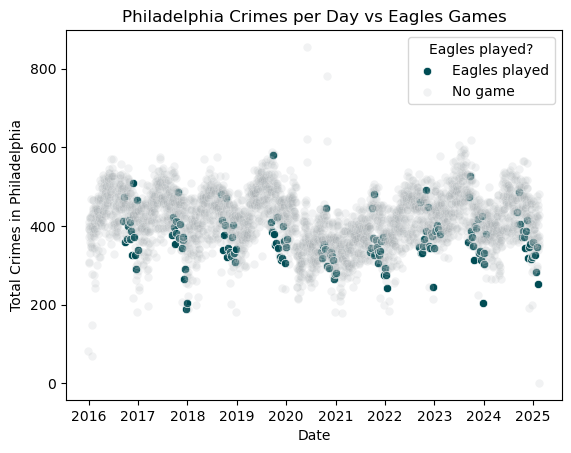

In [111]:
EAGLES_GREEN = "#004C54"
EAGLES_SILVER = "#A5ACAF"

df = crime_count_eagles_by_day

sns.scatterplot(
    data=df[df["game_played"]],
    x = "dispatch_date", y = "crime_count",
    color = EAGLES_GREEN, alpha = 1, label = "Eagles played"
)

sns.scatterplot(
    data = df[~df["game_played"]],
    x = "dispatch_date", y = "crime_count",
    color = EAGLES_SILVER, alpha = 0.15, label = "No game"
)

plt.title("Philadelphia Crimes per Day vs Eagles Games")
plt.xlabel("Date")
plt.ylabel("Total Crimes in Philadelphia")
plt.legend(title="Eagles played?")

On a glance, it looks like there is some slight correlation between whether or not a game is played and how many crimes are committed. Many of the green dots are on the lower end of the total crimes axis. Let's look at what the pearson correlation is

In [112]:
from scipy.stats import pointbiserialr

r, p = pointbiserialr(crime_count_eagles_by_day["game_played"],
                      crime_count_eagles_by_day["crime_count"])
print("Correlation:", r)
print("p-value:", p)

Correlation: -0.16847908414074098
p-value: 1.1540659417355692e-22


The correlation value of approximately -0.17 indicates a weak negative correlation between whether a game was played and how much crime was committed. 

Next I will look at the data for only days when a game was played.

Text(0, 0.5, 'Total Crimes in Philadelphia')

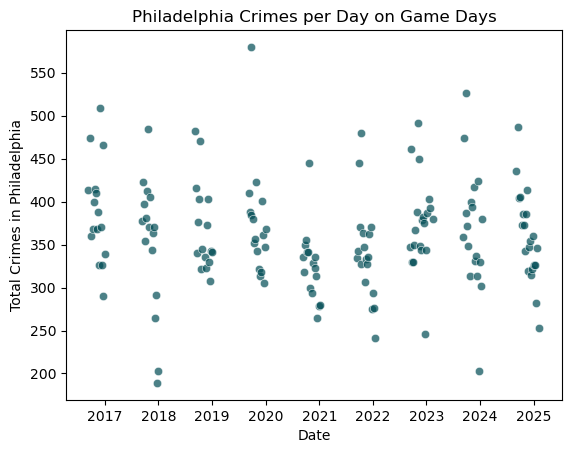

In [113]:
sns.scatterplot(
    data = crime_count_eagles_by_day[crime_count_eagles_by_day["game_played"] == True], 
    x = "dispatch_date", 
    y = "crime_count",  
    color = EAGLES_GREEN, 
    alpha = 0.7
)

plt.title("Philadelphia Crimes per Day on Game Days")
plt.xlabel("Date")
plt.ylabel("Total Crimes in Philadelphia")

Interestingly, every season seems to have a pattern: higher crime in the beginning of the season, and a decline in crime throughout the season. 

Perhaps the city of brotherly love comes together around their favorite franchise and commits less crime as the season progresses, or perhaps the temperature is getting colder and less crimes are being committed in general because of the weather changes that correspond with the Football season every year. If you look closely at the previous graph which shows all crime and colors based on whether the Eagles played, there is a similar pattern in the data from the days the Eagles didn't play. So it could be that this trend is more because of the temperature changes that happen to take place every year during the Football season.

### Crime Subplots
Next, I would like to split the data and graph the distribution for each type of crime to see if stronger relationships exist between different types of crime and whether the Eagles played.

In [114]:
philly_crime_count_by_day_and_crime = philly_crime_incidents.groupby(["dispatch_date", "day", "nfl_time", 'text_general_code']).size().reset_index(name = "crime_count").rename(columns = {"text_general_code":"crime"})
crime_count_eagles_by_day_and_crime = philly_crime_count_by_day_and_crime.merge(eagles_games, left_on = "dispatch_date", right_on = "game_date", how = "left")
crime_count_eagles_by_day_and_crime["game_played"] = crime_count_eagles_by_day_and_crime["home_team"].notna()
crime_count_eagles_by_day_and_crime.head()

,dispatch_date,day,nfl_time,crime,crime_count,playoff_game,game_date,game_time,in_philly,home_team,away_team,home_team_score,away_team_score,eagles_won,game_played
0,2015-12-31,Thursday,Prime Time,Aggravated Assault Firearm,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2015-12-31,Thursday,Prime Time,Aggravated Assault No Firearm,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,2015-12-31,Thursday,Prime Time,All Other Offenses,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,2015-12-31,Thursday,Prime Time,DRIVING UNDER THE INFLUENCE,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,2015-12-31,Thursday,Prime Time,Disorderly Conduct,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


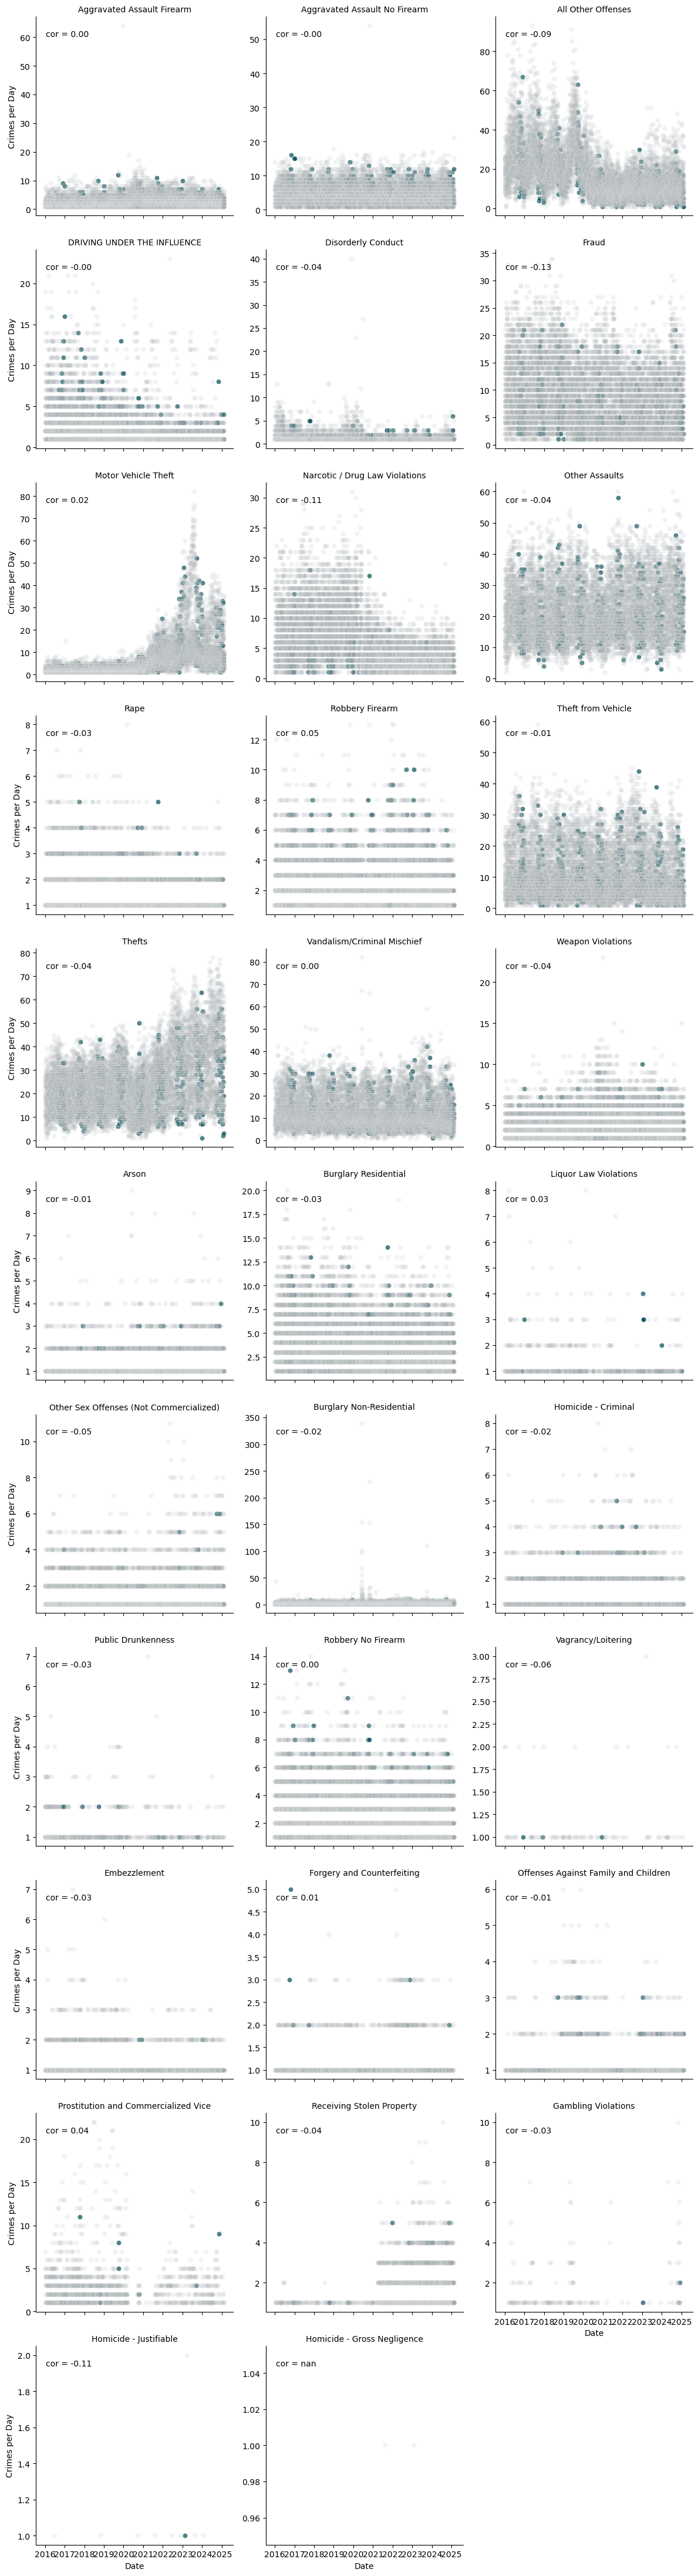

In [129]:
df = crime_count_eagles_by_day_and_crime

df["game_played_num"] = df["game_played"].astype(int)

# Function that plots scatter + adds correlation text
def scatter_with_corr(data, **kwargs):
    ax = plt.gca()
    # scatter by game_played style
    sns.scatterplot(
        data=data[data["game_played"]],
        x="dispatch_date", y="crime_count",
        color="#004C54", alpha=0.7, ax=ax
    )
    sns.scatterplot(
        data=data[~data["game_played"]],
        x="dispatch_date", y="crime_count",
        color="#A5ACAF", alpha=0.15, ax=ax
    )
    # compute correlation for this crime type
    with np.errstate(invalid="ignore", divide="ignore"):
        corr = data["crime_count"].corr(data["game_played_num"])
    ax.text(0.05, 0.9, f"cor = {corr:.2f}", transform=ax.transAxes)

# Build grid
g = sns.FacetGrid(df, col="crime", col_wrap=3, height=4, sharey=False)
g.map_dataframe(scatter_with_corr)

g.set_axis_labels("Date", "Crimes per Day")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

### Fraud
Looking at these graphs, I'm actually quite surprised. I had expected crimes like DUIs, Disorderly Conduct, and different types of assaults to be much more coordinated with Eagles' games than they turned out to be. It seemed almost intuitive for these crimes to go up when the Eagles play because the alcohol consumption almost certainly goes up during the games. Meanwhile, the crime with the highest correlation is Fraud which seems out of left field. Let's look more closely at this.

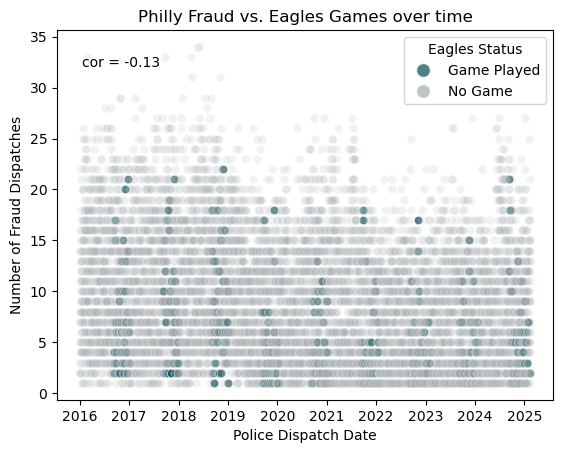

In [116]:
from matplotlib.lines import Line2D

ax = plt.gca()
data = df[df["crime"] == "Fraud"]
# scatter by game_played style
sns.scatterplot(
    data=data[data["game_played"]],
    x="dispatch_date", y="crime_count",
    color="#004C54", alpha=0.7, ax=ax
)
sns.scatterplot(
    data=data[~data["game_played"]],
    x="dispatch_date", y="crime_count",
    color="#A5ACAF", alpha=0.15, ax=ax
)
# compute correlation for this crime type
corr = data["crime_count"].corr(data["game_played_num"])
ax.text(0.05, 0.9, f"cor = {corr:.2f}", transform=ax.transAxes)
ax.set_title("Philly Fraud vs. Eagles Games over time")
ax.set_xlabel("Police Dispatch Date")
ax.set_ylabel("Number of Fraud Dispatches")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Game Played',
           markerfacecolor="#004C54", markersize=10, alpha=0.7),
    Line2D([0], [0], marker='o', color='w', label='No Game',
           markerfacecolor="#A5ACAF", markersize=10, alpha=0.7)
]

ax.legend(handles=legend_elements, title="Eagles Status", loc="upper right")
plt.savefig("fraud_vs_eagles.png", dpi=300, bbox_inches="tight")

Why is it that fraud dispatches are lower when the Eagles are playing? Are Philly's fraudsters taking the day off to watch the big game? Possibly, but likely not. What's more likely is that there is a correlation between these two variables because the Eagles predominantly play on Sundays, and there are less fraud dispatches during the weekend. To check this, I will graph fraud dispatches and color by whether or not it was a weekend.

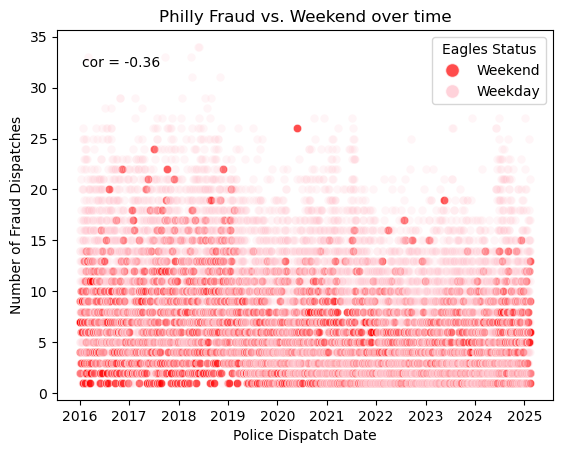

In [117]:
from matplotlib.lines import Line2D

data = df[df["crime"] == "Fraud"].copy()

def is_weekend(record):
    if record["day"] == "Saturday" or record["day"] == "Sunday":
        return True
    return False

data["weekend"] = data.apply(lambda record: is_weekend(record), axis = 1)

ax = plt.gca()
# scatter by game_played style
sns.scatterplot(
    data=data[data["weekend"]],
    x="dispatch_date", y="crime_count",
    color="red", alpha=0.7, ax=ax
)
sns.scatterplot(
    data=data[~data["weekend"]],
    x="dispatch_date", y="crime_count",
    color="pink", alpha=0.15, ax=ax
)
# compute correlation for this crime type
corr = data["crime_count"].corr(data["weekend"])
ax.text(0.05, 0.9, f"cor = {corr:.2f}", transform=ax.transAxes)
ax.set_title("Philly Fraud vs. Weekend over time")
ax.set_xlabel("Police Dispatch Date")
ax.set_ylabel("Number of Fraud Dispatches")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Weekend',
           markerfacecolor="red", markersize=10, alpha=0.7),
    Line2D([0], [0], marker='o', color='w', label='Weekday',
           markerfacecolor="pink", markersize=10, alpha=0.7)
]

ax.legend(handles=legend_elements, title="Eagles Status", loc="upper right")

We can see a moderately strong negative correlation between whether or not it's the weekend and how many dispatches there were for frauds. This leads me to think that what's most likely is that the correlation that exists between whether the Eagles played or not is mostly because the Eagles happen to predominantly play on the weekend. It remains to be seen why fraud dispatches go down on weekends, and exploring the answer to that question is beyond the scope of this project.

## Relationship between Eagles' victory and Crime
Next, I would like to visualize what the total crime statistics look like when the Eagles win vs lose.

Text(0, 0.5, 'Did the Eagles win?')

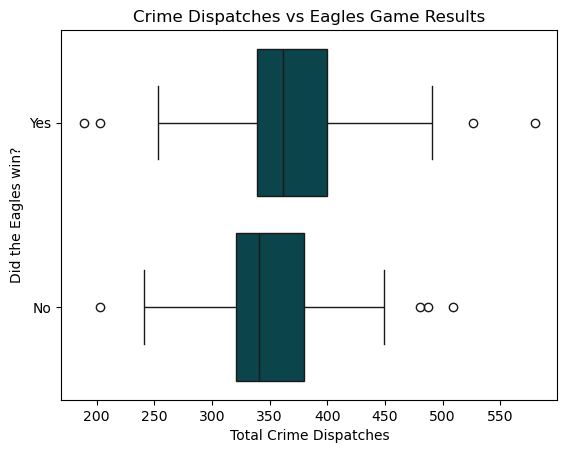

In [126]:
eagles_played = crime_count_eagles_by_day[crime_count_eagles_by_day["game_played"] == True].copy()
eagles_played["eagles_won"] = eagles_played.apply(lambda game: "Yes" if game["eagles_won"] == 1 else "No", axis = 1)

sns.boxplot(
    data = eagles_played,
    x = "crime_count",
    y = "eagles_won",
    color = EAGLES_GREEN,
    orient = "h"
)
plt.title("Crime Dispatches vs Eagles Game Results")
plt.xlabel("Total Crime Dispatches")
plt.ylabel("Did the Eagles win?")

Surprisingly, the range of crime is a little different when the Eagles win as opposed to lose. Both categories have a similar 1st quartile value, but the "yes" range's 3rd quartile value is somewhat higher than the "no" range's. At the same time, the median is roughly equivalent for both categories, and even the upper end of the range is still relatively close. Because of this, I would say that this graph doesn't really suggest there is a relationship between crime and whether or not the Eagles won.

## Time of Day
Again assuming that the Eagles played, I would like to see if there is a difference in crime based on the time the game is.

Text(0, 0.5, 'Game Time')

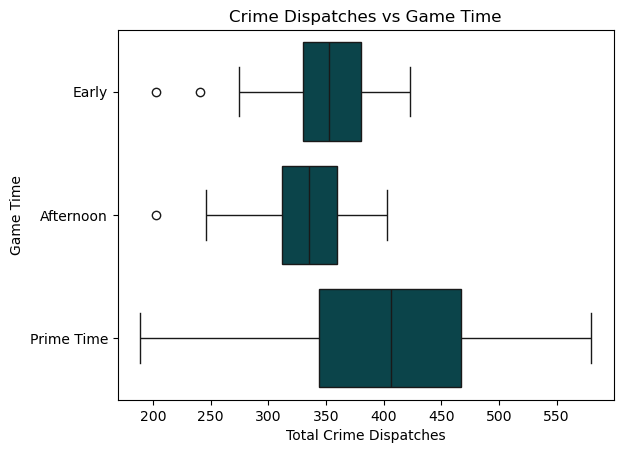

In [119]:
sns.boxplot(
    data = eagles_played,
    x = "crime_count",
    y = "game_time",
    order = ["Early", "Afternoon", "Prime Time"],
    color = EAGLES_GREEN,
    orient = "h"
)
plt.title("Crime Dispatches vs Game Time")
plt.xlabel("Total Crime Dispatches")
plt.ylabel("Game Time")

There is a pretty substantial gap between the median total crime dispatches when the Eagles play in Prime Time and when they play earlier in the day. Yet at the same time, the range for Prime Time is substantially wider than either of the other two time slots. My suspicion is that this is a result of weeknight football. I would imagine that crime is significantly higher on weeknights as opposed to Sunday night, and any time the Eagles play on a weeknight, it will be in the Prime Time slot. To check this, I will make a graph of crime dispatches on Sundays as opposed to Mondays and Thursdays, and see if there is a similar trend.

Text(0, 0.5, 'Day')

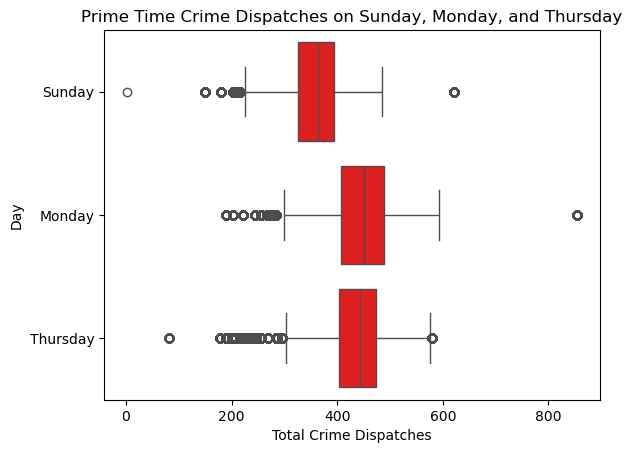

In [127]:
prime_time_crimes = philly_crime_incidents.copy()
prime_time_crimes = prime_time_crimes[(prime_time_crimes["day"] == "Sunday") | (prime_time_crimes["day"] == "Monday") | (prime_time_crimes["day"] == "Thursday")]

prime_time_crimes["crime_count"] = prime_time_crimes.groupby("dispatch_date")["dispatch_date"].transform("count")

sns.boxplot(
    data = prime_time_crimes,
    x = "crime_count",
    y = "day",
    order = ["Sunday", "Monday", "Thursday"],
    color = "red",
    orient = "h"
)
plt.title("Prime Time Crime Dispatches on Sunday, Monday, and Thursday")
plt.xlabel("Total Crime Dispatches")
plt.ylabel("Day")

This graph seems very similar to the graph of crime dispatches vs time slots. Just like the prime time median was higher in the time slots graph, the crime dispatches on Mondays and Thursdays have a higher median and 3rd quartile value than the crime dispatches on Sunday. This shows a plausible explanation for why dispatches seem to be higher when the Eagles play in prime time.

## Crime Location
Lastly, I want to visualize some of the location data about crimes, and see what it looks like when the Eagles are play in Philly. First of all, I will just visualize all of the Philly crimes on a scatter plot of longitude and latitude.

<Axes: xlabel='lat', ylabel='lng'>

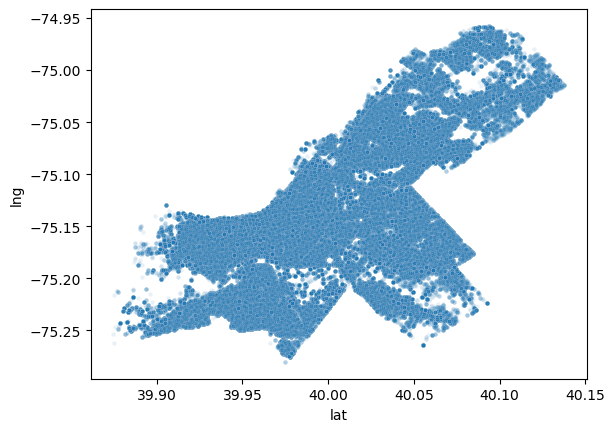

In [121]:
location_data = philly_crime_incidents[philly_crime_incidents["lat"] < 42] # remove an outlier

sns.scatterplot(
    data = location_data,
    x = "lat",
    y = "lng",
    alpha = 0.1,
    s = 10
)

From this graph, we see basically the map of Philadelphia. Judging by the graph one could conclude that crime happens everywhere, but this graph doesn't really represent the frequency of crimes. Next I will visualize the frequency of crimes using a hexbin plot. This will help show us which parts of the city typically have the most crimes reported.

Text(0, 0.5, 'Longitude')

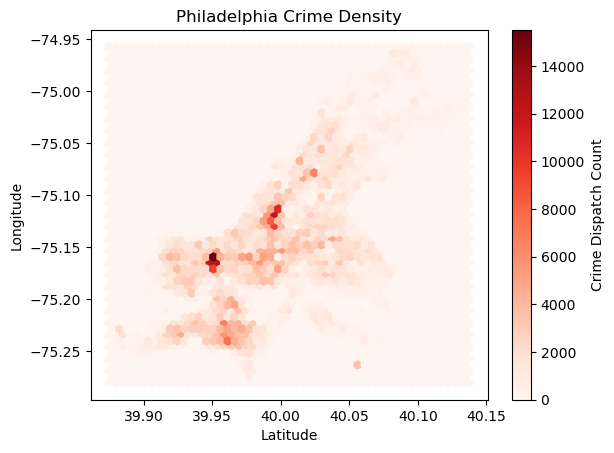

In [131]:
plt.hexbin(
    location_data["lat"],
    location_data["lng"],
    gridsize=50,
    cmap="Reds"
)
plt.title("Philadelphia Crime Density")
plt.colorbar(label="Crime Dispatch Count")
plt.xlabel("Latitude")
plt.ylabel("Longitude")


We can see from this this hexbin plot that while crimes have been reported in nearly every part of the city, there are specific areas in the city where crime happens the most. In order to look at what potentially changes when the , we will need to see where Lincoln Financial Field (the Eagles' home stadium) lies in this graph.

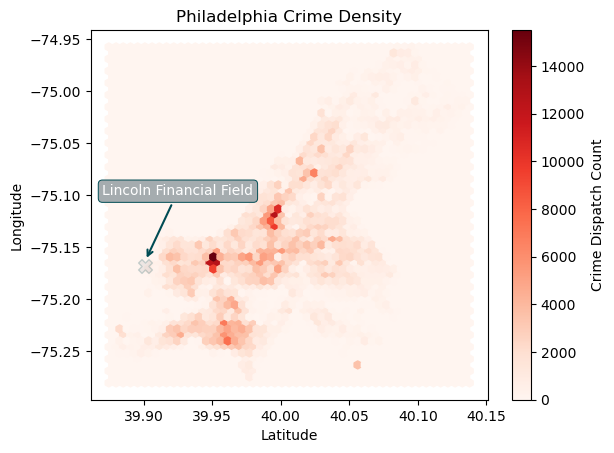

In [123]:
plt.hexbin(
    location_data["lat"],
    location_data["lng"],
    gridsize=50,
    cmap="Reds"
)
plt.title("Philadelphia Crime Density")
plt.colorbar(label="Crime Dispatch Count")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

# Coordinates of the stadium
lat, lng = 39.9014, -75.1676

# Plot the marker
plt.scatter(
    lat, lng,
    color=EAGLES_SILVER, s=100, marker="X", edgecolor=EAGLES_GREEN, zorder=5,
    alpha = 0.2
)

# Add annotation with arrow
plt.annotate(
    "Lincoln Financial Field",
    xy=(lat, lng + 0.005),               # point being annotated
    xytext=(39.87, -75.10),      # text position
    arrowprops=dict(
        arrowstyle="->",         # simple arrow
        color=EAGLES_GREEN,
        lw=1.5
    ),
    fontsize=10,
    color = "White",
    bbox=dict(boxstyle="round,pad=0.3", fc=EAGLES_SILVER, ec=EAGLES_GREEN, lw=0.7)
)

plt.show()


We can see that the area around Lincoln Financial Field does not have many crime dispatches at all. Now we will visualize the frequency only on the days that the Eagles played in Philly, and see if the frequency goes up.

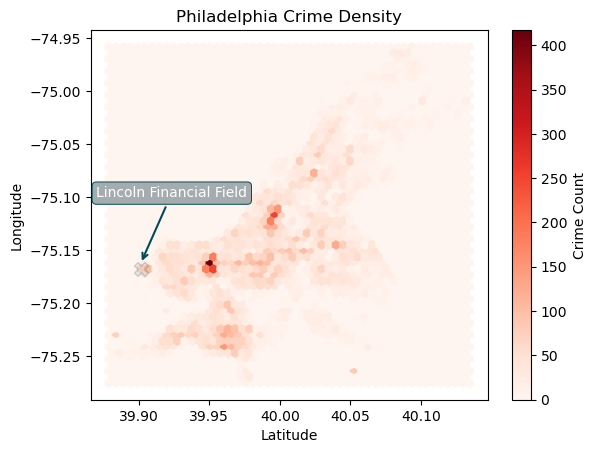

In [124]:
philly_eagles_home_crime = philly_crime_incidents.merge(eagles_games, left_on = "dispatch_date", right_on = "game_date", how = "inner")
philly_eagles_home_crime = philly_eagles_home_crime[philly_eagles_home_crime["in_philly"] == 1]

plt.hexbin(
    philly_eagles_home_crime["lat"],
    philly_eagles_home_crime["lng"],
    gridsize=50,
    cmap="Reds"
)
plt.title("Philadelphia Crime Density")
plt.colorbar(label="Crime Count")
plt.xlabel("Latitude")
plt.ylabel("Longitude")

# Coordinates of the stadium
lat, lng = 39.9014, -75.1676

# Plot the marker
plt.scatter(
    lat, lng,
    color=EAGLES_SILVER, s=100, marker="X", edgecolor=EAGLES_GREEN, zorder=5,
    alpha = 0.2
)

# Add annotation with arrow
plt.annotate(
    "Lincoln Financial Field",
    xy=(lat, lng + 0.005),               # point being annotated
    xytext=(39.87, -75.10),      # text position
    arrowprops=dict(
        arrowstyle="->",         # simple arrow
        color=EAGLES_GREEN,
        lw=1.5
    ),
    fontsize=10,
    color = "White",
    bbox=dict(boxstyle="round,pad=0.3", fc=EAGLES_SILVER, ec=EAGLES_GREEN, lw=0.7)
)

plt.show()

Interestingly, we can see that dispatches to Lincoln Financial field go up when the Eagles are playing at home. This is not super surprising because the stadium is almost certainly going to have more crime when it is being used by the public than when it is not being used. At the same time, the density appears to go down in some other parts of the city that displayed a higher density in the previous graph.

# Conclusion
Overall, this project doesn't suggest much in regards to a relationship between Philly Crime and the Eagles game schedule. This is not surprising because Philadelphia is a big place with a lot of people, and while it sometimes feels like the world revolves around sports, the vast majority of crime trends probably exist in isolation from what's going on with the Eagles. This project did definitely give some useful insights into overall crime trends (on weekends vs weekdays), and with more data some of the observed phenomenon can definitely be investigated.